In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, roc_curve, auc
import itertools
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from tqdm import tqdm


In [2]:
def flux_to_class(flux, only_main=False):
    """
    Convert flux values to solar flare classes (A, B, C, M, X).
    only_main=True returns just the main letter (A/B/C/M/X).
    """
    if isinstance(flux, str):
        flux = float(flux.replace("e", "E"))
    if flux < 1e-7:
        return 'A' if only_main else 'A (<1e-7)'
    elif flux < 1e-6:
        return 'B' if only_main else 'B (1e-7–1e-6)'
    elif flux < 1e-5:
        return 'C' if only_main else 'C (1e-6–1e-5)'
    elif flux < 1e-4:
        return 'M' if only_main else 'M (1e-5–1e-4)'
    else:
        return 'X' if only_main else 'X (>1e-4)'


In [3]:
def create_simple_image_set(base_path, balance=True):
    """
    Loads images, crops, resizes to 28x28, normalizes, and flattens.
    Returns balanced dataset (equal flares and non-flares if balance=True).
    """
    meta_csv = os.path.join(base_path, 'meta_data.csv')
    df = pd.read_csv(meta_csv, parse_dates=["start", "end"], index_col="id")

    images, labels = [], []

    for row_id, row in df.iterrows():
        ar_nr, p = row_id.split("_", 1)
        img_path = os.path.join(base_path, ar_nr, p)
        if not os.path.isdir(img_path):
            continue

        for img_name in os.listdir(img_path):
            if img_name.endswith('_magnetogram.jpg'):
                im = Image.open(os.path.join(img_path, img_name)).convert('L')
                im = im.crop((44, 44, 212, 212))
                im = im.resize((28, 28), Image.Resampling.LANCZOS)
                im = np.array(im) / 255.0
                label = int(flux_to_class(row['peak_flux'], only_main=True) in ['M', 'X'])
                images.append(im)
                labels.append(label)

    X, Y = np.array(images), np.array(labels)

    if balance:
        flare_idx = np.where(Y == 1)[0]
        nonflare_idx = np.where(Y == 0)[0]
        np.random.shuffle(nonflare_idx)
        nonflare_idx = nonflare_idx[:len(flare_idx)]
        idx = np.concatenate([flare_idx, nonflare_idx])
        np.random.shuffle(idx)
        X, Y = X[idx], Y[idx]

    return X, Y

# Load datasets
base_train = "/Users/yashvisingh/Documents/sunpy/data/github_data/SDOBenchmark_full/training"
base_test = "/Users/yashvisingh/Documents/sunpy/data/github_data/SDOBenchmark_full/test"

X_train, Y_train = create_simple_image_set(base_train)
X_test, Y_test = create_simple_image_set(base_test)

print(f"Train samples: {X_train.shape}, Test samples: {X_test.shape}")


Train samples: (4050, 28, 28), Test samples: (1360, 28, 28)


In [4]:
# Add channel dimension
X_train_t = torch.tensor(X_train).unsqueeze(1).float()
Y_train_t = torch.tensor(Y_train).float().unsqueeze(1)
X_test_t = torch.tensor(X_test).unsqueeze(1).float()
Y_test_t = torch.tensor(Y_test).float().unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, Y_test_t), batch_size=32)


In [5]:
class SimpleBinaryCNN(nn.Module):
    def __init__(self):
        super(SimpleBinaryCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

model = SimpleBinaryCNN()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")


Using device: mps


In [6]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(test_loader))
    print(f"Epoch {epoch+1}/{epochs}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}")


Epoch 1/10: Train Loss=0.6320, Val Loss=0.5640


Epoch 2/10: Train Loss=0.5288, Val Loss=0.5549


Epoch 3/10: Train Loss=0.5126, Val Loss=0.5871


Epoch 4/10: Train Loss=0.5058, Val Loss=0.5553


Epoch 5/10: Train Loss=0.4931, Val Loss=0.5503


Epoch 6/10: Train Loss=0.4787, Val Loss=0.5540


Epoch 7/10: Train Loss=0.4730, Val Loss=0.5927


Epoch 8/10: Train Loss=0.4621, Val Loss=0.5461


Epoch 9/10: Train Loss=0.4571, Val Loss=0.5630


Epoch 10/10: Train Loss=0.4396, Val Loss=0.5755


Accuracy: 0.7375
 F1 Score: 0.7519

Classification Report:
              precision    recall  f1-score   support

   Non-Flare       0.77      0.68      0.72       680
       Flare       0.71      0.80      0.75       680

    accuracy                           0.74      1360
   macro avg       0.74      0.74      0.74      1360
weighted avg       0.74      0.74      0.74      1360



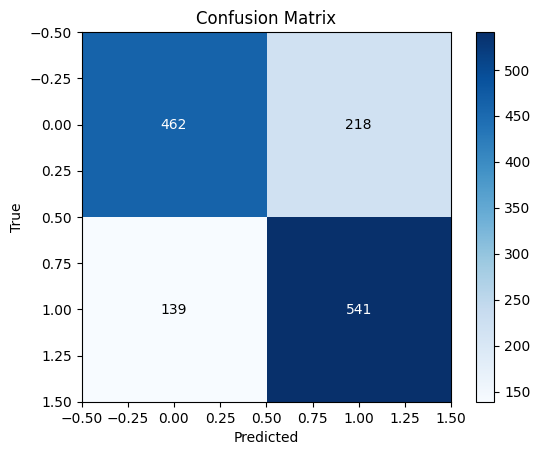

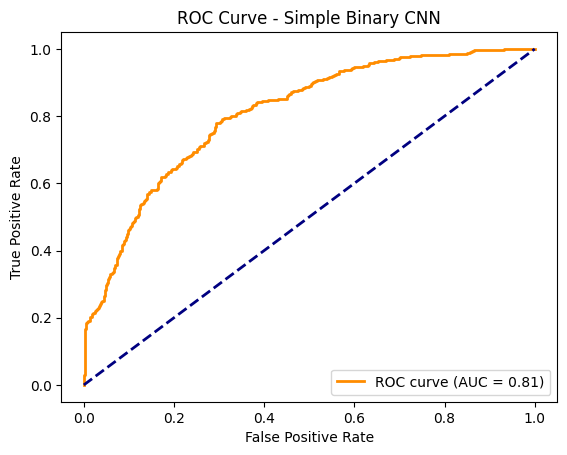

True Skill Statistic (TSS): 0.4750


In [7]:
# ---- Evaluation ----
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = (outputs.cpu().numpy() > 0.5).astype(int)
        probs = outputs.cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()
y_prob = np.array(y_prob).flatten()

# Accuracy & F1
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f" F1 Score: {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Non-Flare", "Flare"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")
plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Simple Binary CNN')
plt.legend(loc="lower right")
plt.show()

# True Skill Statistic (TSS)
tn, fp, fn, tp = cm.ravel()
TSS = tp / (tp + fn) - fp / (fp + tn)
print(f"True Skill Statistic (TSS): {TSS:.4f}")
